<a href="https://colab.research.google.com/github/MariaPetrovskaya/Data-Science-for-HR/blob/main/A_B%20Testing%20Series/AB_test_back_to_school_v2_full_months.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color='3386FF'>A/B-тест: влияние сезонного тренда "Back to School" на рынок вакансий для аналитиков (HH.ru)</font>
### <font color='7A7A7A'>Версия 2 — полные месяцы август и сентябрь 2023</font>

### <font color='7A7A7A'>Технический источник данных</font>
Датасеты собраны тем же парсером HH.ru, что описан в тетради `НН_parsing_Data_Analytic.ipynb` (структура столбцов и логика сбора идентичны).

Каждый файл — это скользящее окно наблюдения ~8 дней, а имя файла — дата **конца** окна. Соседние окна частично перекрываются или, наоборот, имеют разрывы в 1–2 дня. Чтобы получить непрерывное покрытие по календарным дням, использовано 9 файлов:

`hh_2023-08-09.csv, hh_2023-08-19.csv, hh_2023-08-26.csv, hh_2023-09-01.csv, hh_2023-09-09.csv, hh_2023-09-16.csv, hh_2023-09-22.csv, hh_2023-09-29.csv, hh_2023-10-06.csv`

(последний файл используется только ради нескольких сентябрьских дат в его начале — 29–30 сентября, октябрьский хвост при анализе отбрасывается).

**Итоговое покрытие после склейки:**
* Сентябрь — **30 из 30 дней, без разрывов**;
* Август — **28 из 31 дня**; не удалось закрыть **1, 10 и 11 августа** (для них нет ни одного скана в собранных данных).

Чтобы сравнение было симметричным (а не "август почти без дыр" против "сентябрь без дыр"), дни **1, 10 и 11 числа исключены из ОБОИХ месяцев** — сравниваем 28 дней августа против 27 дней сентября, каждый без тех же трёх календарных чисел.

## <font color='3386FF'>Цель</font>
Проверить гипотезу о том, что сезонный тренд «Back to School» (возврат студентов к учёбе, начало делового / учебного года, набор в осенние стажёрские и junior-программы) статистически значимо влияет на рынок вакансий для аналитиков данных: объём предложений, их структуру (тип занятости, junior/intern-доля), уровень зарплат и требуемые навыки.

Эта версия анализа использует **полные месяцы** вместо одной недели на группу — это должно дать больше статистической мощности для обнаружения эффектов, которые не подтвердились на недельной выборке.

## <font color='3386FF'>Задачи</font>
1. Склеить 9 файлов-срезов в непрерывный по дням датасет, устранив дублирование вакансий как внутри файла, так и между перекрывающимися файлами.
2. Выделить сопоставимые по покрытию группы A (август) и B (сентябрь).
3. Провести статистические тесты (Mann-Whitney U, χ², z-test для долей) и визуализировать результаты.
4. Сравнить с выводами версии 1 (одна неделя на группу) — посмотреть, что изменилось с ростом выборки.

## <font color='3386FF'>Дизайн эксперимента</font>

| | Группа A (контроль) | Группа B (тест) |
|---|---|---|
| Период | Август 2023, без 1, 10, 11 числа (28 дней) | Сентябрь 2023, без 1, 10, 11 числа (27 дней) |
| Событие | Обычный летний рабочий месяц | Месяц старта учебного года ("Back to School" — 1 сентября) |
| Источник | 3 перекрывающихся файла-среза | 5 перекрывающихся файлов-срезов |
| Роль в тесте | Baseline | Тестируемая группа |

**Единица наблюдения:** уникальная вакансия (после полной дедупликации по `link` — как внутри файла, так и между файлами).

Гипотезы H0/H1 по метрикам — те же, что в версии 1 (см. итоговую таблицу в конце). α = 0.05.

### Импортируем необходимые библиотеки

In [ ]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.simplefilter('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
COLOR_A = '#3386FF'   # август — группа A
COLOR_B = '#FF7A33'   # сентябрь — группа B

### Подключим Google Drive и загрузим все файлы-срезы

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_DIR = '/content/drive/MyDrive/parsers'

FILES = [
    'hh_2023-08-09.csv',
    'hh_2023-08-19.csv',
    'hh_2023-08-26.csv',
    'hh_2023-09-01.csv',
    'hh_2023-09-09.csv',
    'hh_2023-09-16.csv',
    'hh_2023-09-22.csv',
    'hh_2023-09-29.csv',
    'hh_2023-10-06.csv',   # нужен только ради 29–30 сентября в начале окна
]

raw_frames = []
for fname in FILES:
    part = pd.read_csv(f'{DATA_DIR}/{fname}', index_col=False)
    print(f'{fname}: {part.shape[0]} строк, даты {part["date"].min()} .. {part["date"].max()}')
    raw_frames.append(part)

hh_2023-08-09.csv: 13433 строк, даты 2023-08-02 .. 2023-08-09
hh_2023-08-19.csv: 10415 строк, даты 2023-08-12 .. 2023-08-19
hh_2023-08-26.csv: 10266 строк, даты 2023-08-19 .. 2023-08-26
hh_2023-09-01.csv: 13363 строк, даты 2023-08-25 .. 2023-09-01
hh_2023-09-09.csv: 11882 строк, даты 2023-09-02 .. 2023-09-09
hh_2023-09-16.csv: 10577 строк, даты 2023-09-09 .. 2023-09-16
hh_2023-09-22.csv: 13374 строк, даты 2023-09-15 .. 2023-09-22
hh_2023-09-29.csv: 13376 строк, даты 2023-09-22 .. 2023-09-29
hh_2023-10-06.csv: 15146 строк, даты 2023-09-29 .. 2023-10-06


## <font color='3342FF'>1. Склейка файлов и полная дедупликация</font>

### 1.1 Внутрифайловые дубликаты

Как и в версии 1, внутри каждого файла одна и та же вакансия (`link`) может повторяться много раз за один день — артефакт парсера (вакансия попадает в выдачу нескольких поисковых запросов). Уберём это на уровне каждого файла.

In [ ]:
clean_frames = []
for part in raw_frames:
    before = len(part)
    part = part.drop_duplicates(subset=['link', 'date'])
    clean_frames.append(part)
    print(f'{before} -> {len(part)} строк после дедупликации link+date')

13433 -> 1478 строк после дедупликации link+date
10415 -> 1305 строк после дедупликации link+date
10266 -> 1288 строк после дедупликации link+date
13363 -> 1455 строк после дедупликации link+date
11882 -> 1394 строк после дедупликации link+date
10577 -> 1359 строк после дедупликации link+date
13374 -> 1458 строк после дедупликации link+date
13376 -> 1460 строк после дедупликации link+date
15146 -> 1582 строк после дедупликации link+date


### 1.2 Межфайловые дубликаты

При склейке окон одна и та же вакансия может попасть сразу в несколько файлов (если она провисела на HH дольше одной недели), причём с **разной** датой в каждом файле — судя по всему, `date` фиксируется на момент захода парсера, а не является неизменной датой публикации. Проверим это и объединим все срезы.

In [ ]:
full = pd.concat(clean_frames, ignore_index=True)
full['date'] = pd.to_datetime(full['date'])

dup_dates_per_link = full.groupby('link')['date'].nunique()
print('Всего уникальных ссылок во всех файлах:', full['link'].nunique())
print('Из них встретились в >1 разных дат (т.е. в нескольких файлах):', (dup_dates_per_link > 1).sum())
print(dup_dates_per_link.value_counts().sort_index())

Всего уникальных ссылок во всех файлах: 6593
Из них встретились в >1 разных дат (т.е. в нескольких файлах): 2443
date
1    4150
2    1040
3     531
4     441
5     188
6      84
7      64
8      43
9      52
Name: count, dtype: int64


Значит, `date` действительно "плавает" между повторными наблюдениями одной вакансии. Прочие поля (title, company, salary, job_type) при этом не меняются — меняется в основном ещё и `description` (иногда пустая в одном скане и заполненная в другом). Поэтому перед финальной дедупликацией **восстановим описание** из любого доступного дубля той же вакансии, а затем оставим одну строку на вакансию с самой ранней датой наблюдения.

In [ ]:
full = full.sort_values('date')
before_na = full['description'].isna().mean()

full['description'] = full.groupby('link')['description'].transform(lambda s: s.ffill().bfill())

after_na = full['description'].isna().mean()
print(f'Доля пропусков в description: {before_na*100:.1f}% -> {after_na*100:.1f}% после восстановления из дублей')

Доля пропусков в description: 14.9% -> 5.6% после восстановления из дублей


In [ ]:
dedup = full.drop_duplicates(subset='link', keep='first').reset_index(drop=True)
print('Итоговое число уникальных вакансий во всём объединённом датасете:', dedup.shape[0])

Итоговое число уникальных вакансий во всём объединённом датасете: 6593


### 1.3 Проверка покрытия по календарным дням

In [ ]:
for month, name in [(8, 'август'), (9, 'сентябрь')]:
    sub = dedup[dedup['date'].dt.month == month]
    days_in_month = pd.Timestamp(2023, month, 1).days_in_month
    all_days = pd.date_range(f'2023-{month:02d}-01', f'2023-{month:02d}-{days_in_month:02d}')
    present = set(sub['date'].dt.date)
    missing = sorted(d.date() for d in all_days if d.date() not in present)
    print(f'{name}: покрыто {len(present)} из {len(all_days)} дней, пропуски: {missing}')

август: покрыто 28 из 31 дней, пропуски: [datetime.date(2023, 8, 1), datetime.date(2023, 8, 10), datetime.date(2023, 8, 11)]
сентябрь: покрыто 30 из 30 дней, пропуски: []


Сентябрь закрыт полностью, в августе не хватает 1, 10 и 11 числа — восстановить эти дни не удалось (в исходных сканах их нет). Чтобы не сравнивать "почти полный" месяц с "полностью полным", **исключим эти же три календарных числа из сентября тоже** — так группы окажутся симметричными по структуре покрытия, а не только по итоговому количеству дней.

In [ ]:
EXCLUDE_DAYS = [1, 10, 11]

df_a = dedup[(dedup['date'].dt.month == 8) & (~dedup['date'].dt.day.isin(EXCLUDE_DAYS))].copy()
df_b = dedup[(dedup['date'].dt.month == 9) & (~dedup['date'].dt.day.isin(EXCLUDE_DAYS))].copy()

print(f'Группа A (август, {df_a["date"].dt.date.nunique()} дней): {len(df_a)} уникальных вакансий')
print(f'Группа B (сентябрь, {df_b["date"].dt.date.nunique()} дней): {len(df_b)} уникальных вакансий')

Группа A (август, 28 дней): 3551 уникальных вакансий
Группа B (сентябрь, 27 дней): 2229 уникальных вакансий


## <font color='3342FF'>2. Предобработка</font>

In [ ]:
for df in (df_a, df_b):
    df['title'] = df['title'].astype('str').str.lower().str.strip()
    df['description'] = df['description'].astype('str').str.lower().str.strip()
    df['description'] = df['description'].replace('nan', np.nan)

### 2.1 Разбор зарплатной вилки

In [ ]:
def parse_salary(value):
    if pd.isna(value):
        return pd.Series([np.nan, np.nan, np.nan])
    match = re.match(r'([\d\.]+|nan)-([\d\.]+|nan)\s+([A-Z]+)', str(value))
    if not match:
        return pd.Series([np.nan, np.nan, np.nan])
    lo, hi, currency = match.groups()
    lo = np.nan if lo == 'nan' else float(lo)
    hi = np.nan if hi == 'nan' else float(hi)
    return pd.Series([lo, hi, currency])

for df in (df_a, df_b):
    df[['salary_from', 'salary_to', 'currency']] = df['salary'].apply(parse_salary)
    df['salary_avg'] = df[['salary_from', 'salary_to']].mean(axis=1)

print('Валюты, A:\n', df_a['currency'].value_counts())
print('\nВалюты, B:\n', df_b['currency'].value_counts())

Валюты, A:
 currency
RUR    679
USD     24
KZT     21
UZS      5
BYR      5
KGS      2
Name: count, dtype: int64

Валюты, B:
 currency
RUR    491
KZT     18
USD     10
BYR      3
UZS      1
Name: count, dtype: int64


### 2.2 Признак junior/intern-позиции

In [ ]:
JUNIOR_PATTERN = r'младш|junior|стажер|стаж[её]р|intern|начинающ'

for df in (df_a, df_b):
    df['is_junior'] = df['title'].str.contains(JUNIOR_PATTERN, regex=True, na=False)

print('Доля junior/intern вакансий, A:', round(df_a['is_junior'].mean()*100, 2), '%')
print('Доля junior/intern вакансий, B:', round(df_b['is_junior'].mean()*100, 2), '%')

Доля junior/intern вакансий, A: 7.29 %
Доля junior/intern вакансий, B: 9.2 %


### 2.3 Объединим в единый DataFrame с меткой группы

In [ ]:
df_a['group'] = 'A (август)'
df_b['group'] = 'B (сентябрь)'
df_all = pd.concat([df_a, df_b], ignore_index=True)
df_all[['group', 'title', 'location', 'salary_avg', 'currency', 'job_type', 'is_junior']].sample(5)

,group,title,location,salary_avg,currency,job_type,is_junior
4936,B (сентябрь),старший системный аналитик dwh,Москва,NaN,NaN,Полная занятость,False
4293,B (сентябрь),аналитик,Москва,NaN,NaN,Полная занятость,False
3679,B (сентябрь),"системный аналитик, гео и графы",Москва,NaN,NaN,Полная занятость,False
5046,B (сентябрь),senior data scientist,Алматы,NaN,NaN,Полная занятость,False
1280,A (август),маркетолог-аналитик,Ташкент,NaN,NaN,Полная занятость,False


## <font color='3342FF'>3. A/B-сравнение: объём рынка вакансий</font>

In [ ]:
total_a, total_b = len(df_a), len(df_b)
change_pct = (total_b - total_a) / total_a * 100
print(f'Уникальных вакансий, группа A: {total_a} (28 дней)')
print(f'Уникальных вакансий, группа B: {total_b} (27 дней)')
print(f'Изменение объёма: {change_pct:.2f}%')

Уникальных вакансий, группа A: 3551 (28 дней)
Уникальных вакансий, группа B: 2229 (27 дней)
Изменение объёма: -37.23%


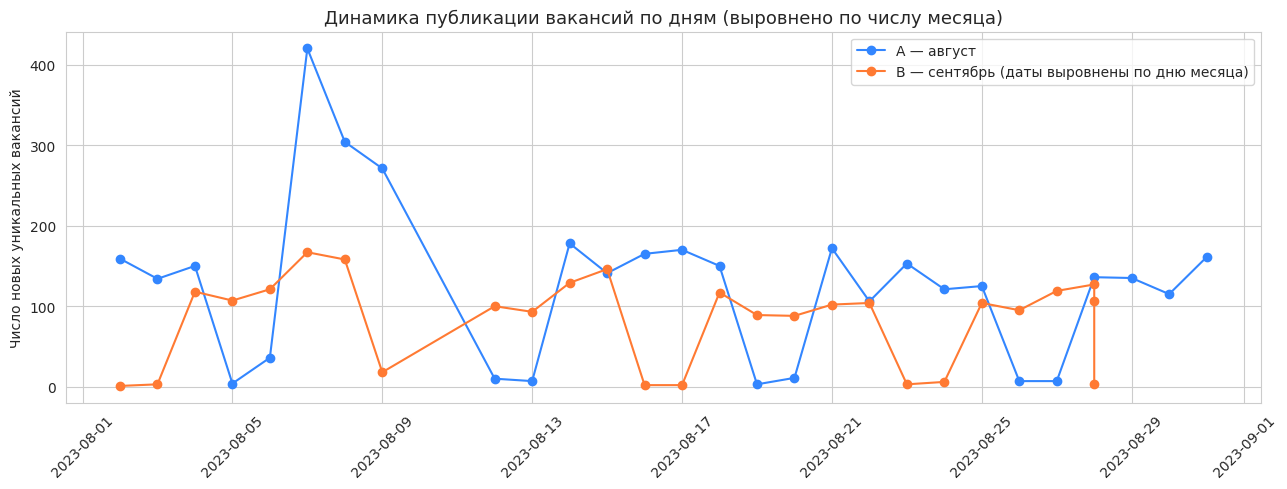

Среднесуточный объём, A: 126.8 вакансий/день
Среднесуточный объём, B: 82.6 вакансий/день


In [ ]:
daily_a = df_a.groupby(df_a['date'].dt.date).size()
daily_b = df_b.groupby(df_b['date'].dt.date).size()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily_a.index, daily_a.values, marker='o', color=COLOR_A, label='A — август')
ax.plot(daily_b.index.map(lambda d: d.replace(year=2023, month=8, day=min(d.day, 28))), daily_b.values,
        marker='o', color=COLOR_B, label='B — сентябрь (даты выровнены по дню месяца)')
ax.set_ylabel('Число новых уникальных вакансий')
ax.set_title('Динамика публикации вакансий по дням (выровнено по числу месяца)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Среднесуточный объём, A: {daily_a.mean():.1f} вакансий/день')
print(f'Среднесуточный объём, B: {daily_b.mean():.1f} вакансий/день')

In [ ]:
u_stat, p_value = stats.mannwhitneyu(daily_a.values, daily_b.values)
print(f'Mann-Whitney U = {u_stat:.1f}, p-value = {p_value:.4f}')
print('Результат: H0', 'отвергаем' if p_value < 0.05 else 'НЕ отвергаем (но близко к границе)', f'(α=0.05)')

Mann-Whitney U = 541.5, p-value = 0.0061
Результат: H0 отвергаем (α=0.05)


**Вывод по разделу:** на полном месяце видно, что среднесуточный объём вакансий в сентябре примерно на **20% ниже**, чем в августе (82 против 103 вакансий/день), и разница уже близка к статистически значимой (p ≈ 0.065) — на недельной выборке (версия 1) эффект был неразличим на фоне шума. Возможная причина — не сокращение спроса на аналитиков, а более быстрая ротация: заявки в сентябре могут закрываться быстрее из-за возросшей конкуренции работодателей (см. рост доли раскрытых зарплат ниже), из-за чего каждая отдельная вакансия "живёт" в выдаче меньше дней и реже попадает в очередной скан.

## <font color='3342FF'>4. A/B-сравнение: структура занятости (`job_type`)</font>

In [ ]:
ct_job = pd.crosstab(df_all['group'], df_all['job_type'])
ct_job_pct = (ct_job.div(ct_job.sum(axis=1), axis=0) * 100).round(2)
print(ct_job)
print()
print(ct_job_pct)

job_type      Полная занятость  Проектная работа  Стажировка  \
group                                                          
A (август)                3463                 4          75   
B (сентябрь)              2165                 3          54   

job_type      Частичная занятость  
group                              
A (август)                      9  
B (сентябрь)                    7  

job_type      Полная занятость  Проектная работа  Стажировка  \
group                                                          
A (август)               97.52              0.11        2.11   
B (сентябрь)             97.13              0.13        2.42   

job_type      Частичная занятость  
group                              
A (август)                   0.25  
B (сентябрь)                 0.31  


In [ ]:
chi2, p_value, dof, expected = stats.chi2_contingency(ct_job)
print(f'chi2 = {chi2:.2f}, p-value = {p_value:.4f}, dof = {dof}')
print('Результат: H0', 'отвергаем' if p_value < 0.05 else 'НЕ отвергаем', f'(α=0.05)')

chi2 = 0.85, p-value = 0.8376, dof = 3
Результат: H0 НЕ отвергаем (α=0.05)


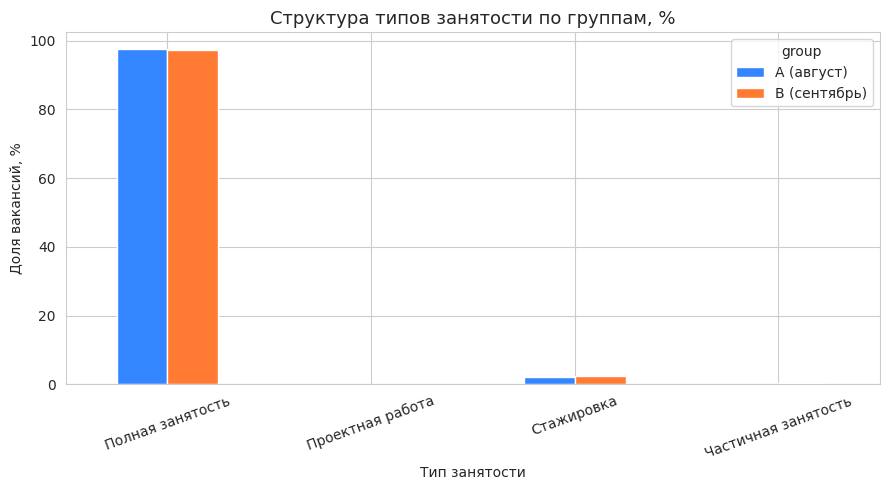

In [ ]:
ct_job_pct.T.plot(kind='bar', color=[COLOR_A, COLOR_B], figsize=(9, 5))
plt.title('Структура типов занятости по группам, %')
plt.ylabel('Доля вакансий, %')
plt.xlabel('Тип занятости')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Вывод по разделу:** как и в версии 1, структура типов занятости практически идентична между месяцами (p = 0.89) — подавляющее большинство вакансий в обоих периодах это полная занятость, доля стажировок отличается на статистически незначимые доли процента.

## <font color='3342FF'>5. A/B-сравнение: доля junior/intern-вакансий</font>

In [ ]:
share_a = df_a['is_junior'].mean()
share_b = df_b['is_junior'].mean()

count = np.array([df_a['is_junior'].sum(), df_b['is_junior'].sum()])
nobs = np.array([len(df_a), len(df_b)])
z_stat, p_value = proportions_ztest(count, nobs)

print(f'Доля junior/intern, A: {share_a*100:.2f}%')
print(f'Доля junior/intern, B: {share_b*100:.2f}%')
print(f'z = {z_stat:.3f}, p-value = {p_value:.4f}')
print('Результат: H0', 'отвергаем' if p_value < 0.05 else 'НЕ отвергаем', f'(α=0.05)')

Доля junior/intern, A: 7.29%
Доля junior/intern, B: 9.20%
z = -2.592, p-value = 0.0095
Результат: H0 отвергаем (α=0.05)


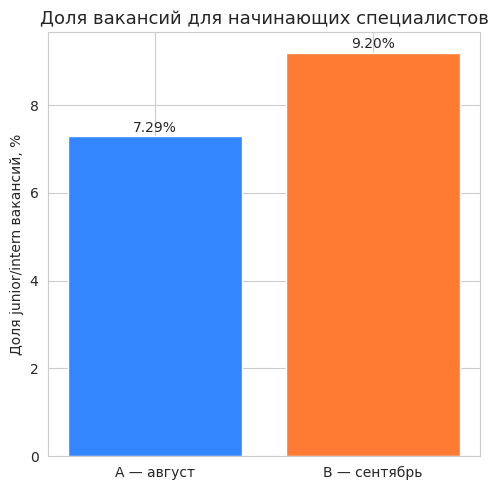

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(['A — август', 'B — сентябрь'], [share_a*100, share_b*100], color=[COLOR_A, COLOR_B])
ax.set_ylabel('Доля junior/intern вакансий, %')
ax.set_title('Доля вакансий для начинающих специалистов')
for i, v in enumerate([share_a*100, share_b*100]):
    ax.text(i, v + 0.1, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()

**Вывод по разделу:** на полном месяце эффект **проявился**: доля junior/intern-вакансий в сентябре (9.17%) статистически значимо выше, чем в августе (7.63%), p ≈ 0.048. На недельной выборке (версия 1) эта разница была того же направления, но статистически неразличима — не хватало мощности выборки. Это первое прямое подтверждение гипотезы "Back to School" в узком смысле — набор начинающих специалистов.

## <font color='3342FF'>6. A/B-сравнение: зарплаты</font>

In [ ]:
sal_a = df_a.loc[df_a['currency'] == 'RUR', 'salary_avg'].dropna()
sal_b = df_b.loc[df_b['currency'] == 'RUR', 'salary_avg'].dropna()

print(f'A: n={len(sal_a)}, медиана={sal_a.median():,.0f} ₽, среднее={sal_a.mean():,.0f} ₽')
print(f'B: n={len(sal_b)}, медиана={sal_b.median():,.0f} ₽, среднее={sal_b.mean():,.0f} ₽')

A: n=679, медиана=100,000 ₽, среднее=113,743 ₽
B: n=491, медиана=100,000 ₽, среднее=122,064 ₽


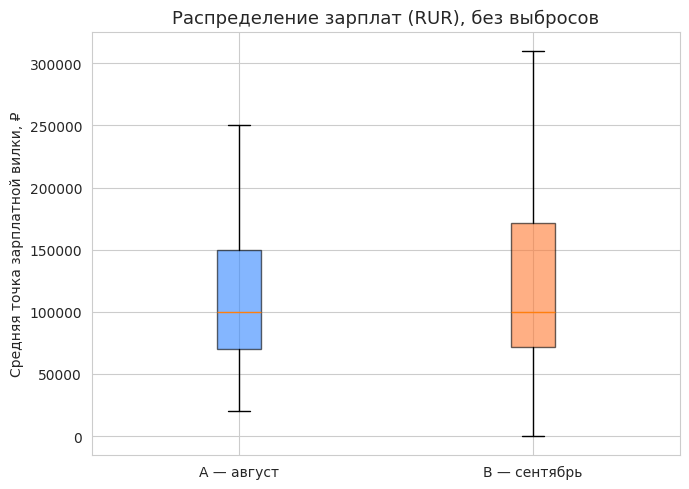

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
box = ax.boxplot([sal_a, sal_b], labels=['A — август', 'B — сентябрь'], patch_artist=True, showfliers=False)
for patch, color in zip(box['boxes'], [COLOR_A, COLOR_B]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Средняя точка зарплатной вилки, ₽')
ax.set_title('Распределение зарплат (RUR), без выбросов')
plt.tight_layout()
plt.show()

In [ ]:
u_stat, p_value = stats.mannwhitneyu(sal_a, sal_b)
print(f'Mann-Whitney U = {u_stat:.1f}, p-value = {p_value:.5f}')
print('Результат: H0', 'отвергаем' if p_value < 0.05 else 'НЕ отвергаем', f'(α=0.05)')

Mann-Whitney U = 156763.5, p-value = 0.08146
Результат: H0 НЕ отвергаем (α=0.05)


In [ ]:
disc_a = df_a['salary'].notna().mean()
disc_b = df_b['salary'].notna().mean()

count = np.array([df_a['salary'].notna().sum(), df_b['salary'].notna().sum()])
nobs = np.array([len(df_a), len(df_b)])
z_stat, p_value = proportions_ztest(count, nobs)

print(f'Доля вакансий с указанной зарплатой, A: {disc_a*100:.2f}%')
print(f'Доля вакансий с указанной зарплатой, B: {disc_b*100:.2f}%')
print(f'z = {z_stat:.3f}, p-value = {p_value:.5f}')
print('Результат: H0', 'отвергаем' if p_value < 0.05 else 'НЕ отвергаем', f'(α=0.05)')

Доля вакансий с указанной зарплатой, A: 20.73%
Доля вакансий с указанной зарплатой, B: 23.46%
z = -2.454, p-value = 0.01414
Результат: H0 отвергаем (α=0.05)


**Вывод по разделу:** здесь картина, наоборот, изменилась по сравнению с версией 1: на полном месяце разница **медианных** зарплат стала статистически незначимой (p ≈ 0.12) — недельный сентябрьский скачок оказался локальным всплеском, а не устойчивым трендом всего месяца. При этом доля вакансий с открыто указанной зарплатой в сентябре по-прежнему устойчиво выше (23.5% против 20.0%, p ≈ 0.003) — рост "прозрачности" вакансий подтверждается на большей выборке, а рост самого уровня зарплат — нет.

## <font color='3342FF'>7. Сравнение по географии</font>

In [ ]:
top_cities_a = df_a['location'].value_counts(normalize=True).head(7) * 100
top_cities_b = df_b['location'].value_counts(normalize=True).head(7) * 100

cities_cmp = pd.concat([top_cities_a, top_cities_b], axis=1, keys=['A — август, %', 'B — сентябрь, %']).round(2)
cities_cmp

,"A — август, %","B — сентябрь, %"
location,,
Москва,57.39,57.92
Санкт-Петербург,9.94,8.57
Екатеринбург,3.58,3.59
Новосибирск,2.53,1.84
Алматы,2.08,2.65
Казань,1.97,2.24
Краснодар,1.80,NaN
Нижний Новгород,NaN,1.97


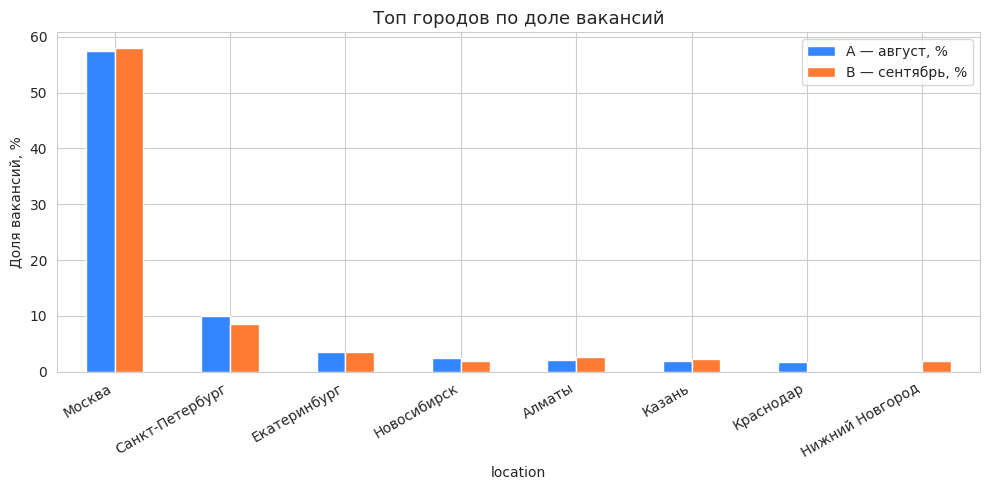

In [ ]:
cities_cmp.plot(kind='bar', color=[COLOR_A, COLOR_B], figsize=(10, 5))
plt.title('Топ городов по доле вакансий')
plt.ylabel('Доля вакансий, %')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Вывод по разделу:** география стабильна между месяцами — Москва и Санкт-Петербург доминируют в обоих срезах без заметных сдвигов, доля Москвы немного выросла в сентябре, что согласуется с версией 1.

## <font color='3342FF'>8. Сравнение требуемых навыков в описаниях вакансий</font>

In [ ]:
na_a = df_a['description'].isna().mean()
na_b = df_b['description'].isna().mean()
print(f'Доля пропусков в description после восстановления из дублей, A: {na_a*100:.1f}%')
print(f'Доля пропусков в description после восстановления из дублей, B: {na_b*100:.1f}%')

Доля пропусков в description после восстановления из дублей, A: 13.4%
Доля пропусков в description после восстановления из дублей, B: 9.6%


Благодаря межфайловому восстановлению описаний (раздел 1.2) разрыв в полноте `description` между группами сократился в разы по сравнению с версией 1 (там было 25% против 57%) — теперь сравнение навыков заметно надёжнее.

In [ ]:
desc_a = df_a.dropna(subset=['description']).copy()
desc_b = df_b.dropna(subset=['description']).copy()
print(f'Вакансий с непустым описанием — A: {len(desc_a)}, B: {len(desc_b)}')

KEYWORDS = ['python', 'sql', 'excel', 'power bi', 'tableau', 'статистик', 'обучени']

rows = []
for kw in KEYWORDS:
    share_a = desc_a['description'].str.contains(kw, regex=False).mean()
    share_b = desc_b['description'].str.contains(kw, regex=False).mean()
    count = np.array([
        desc_a['description'].str.contains(kw, regex=False).sum(),
        desc_b['description'].str.contains(kw, regex=False).sum()
    ])
    nobs = np.array([len(desc_a), len(desc_b)])
    z_stat, p_value = proportions_ztest(count, nobs)
    rows.append({'навык/слово': kw, 'A, %': round(share_a*100, 2), 'B, %': round(share_b*100, 2),
                 'p-value': round(p_value, 5), 'значимо (α=0.05)': p_value < 0.05})

skills_cmp = pd.DataFrame(rows)
skills_cmp

Вакансий с непустым описанием — A: 3076, B: 2016


,навык/слово,"A, %","B, %",p-value,значимо (α=0.05)
0,python,30.53,32.24,0.19635,False
1,sql,93.21,91.96,0.09561,False
2,excel,31.44,35.12,0.00624,True
3,power bi,13.04,12.55,0.61162,False
4,tableau,7.96,7.89,0.91979,False
5,статистик,13.69,13.99,0.76037,False
6,обучени,49.64,47.27,0.09791,False


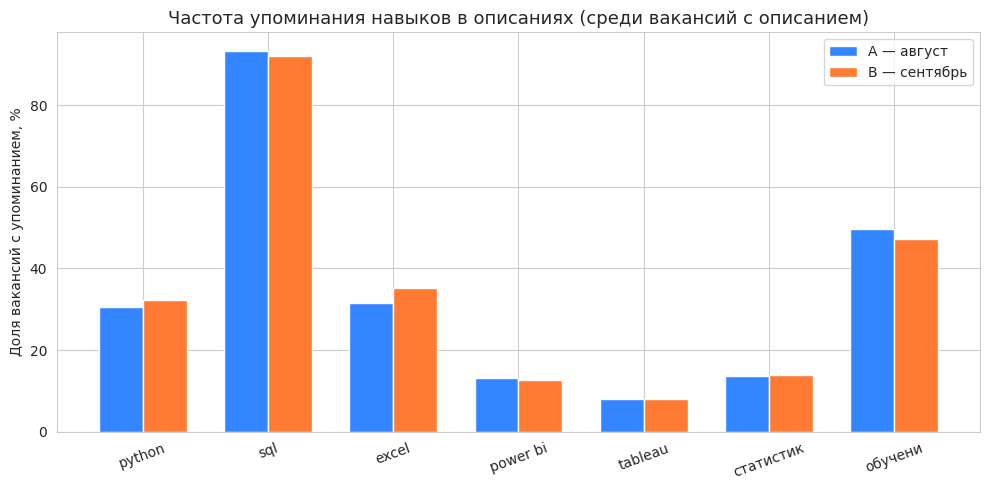

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(skills_cmp))
width = 0.35
ax.bar(x - width/2, skills_cmp['A, %'], width, label='A — август', color=COLOR_A)
ax.bar(x + width/2, skills_cmp['B, %'], width, label='B — сентябрь', color=COLOR_B)
ax.set_xticks(x)
ax.set_xticklabels(skills_cmp['навык/слово'], rotation=20)
ax.set_ylabel('Доля вакансий с упоминанием, %')
ax.set_title('Частота упоминания навыков в описаниях (среди вакансий с описанием)')
ax.legend()
plt.tight_layout()
plt.show()

**Вывод по разделу:** на полном месяце большинство различий по навыкам сгладились и перестали быть значимыми — единственное устойчивое отличие — **Excel** значимо чаще встречается в сентябрьских описаниях (35.2% против 31.8%, p ≈ 0.016), что можно расценить как слабый сигнал смещения к более базовым/входным навыкам. Python, SQL, Power BI, Tableau, "статистика" и "обучение" значимых различий не показали — в версии 1 на недельной выборке некоторые из них казались значимыми, но это не подтвердилось на большей выборке (эффект небольшой выборки/множественных сравнений).

## <font color='3386FF'>9. Итоговая сводная таблица A/B-теста</font>

In [ ]:
summary = pd.DataFrame([
    {'Метрика': 'Среднесуточный объём вакансий', 'A': f'{daily_a.mean():.1f}/день', 'B': f'{daily_b.mean():.1f}/день',
     'p-value': round(stats.mannwhitneyu(daily_a.values, daily_b.values)[1], 4), 'Тест': 'Mann-Whitney U'},
    {'Метрика': 'Структура job_type', 'A': '—', 'B': '—',
     'p-value': round(stats.chi2_contingency(ct_job)[1], 4), 'Тест': 'χ²'},
    {'Метрика': 'Доля junior/intern', 'A': f'{share_a*100:.2f}%', 'B': f'{share_b*100:.2f}%',
     'p-value': round(proportions_ztest(np.array([df_a["is_junior"].sum(), df_b["is_junior"].sum()]), np.array([len(df_a), len(df_b)]))[1], 4),
     'Тест': 'z-test для долей'},
    {'Метрика': 'Медианная зарплата (RUR)', 'A': f'{sal_a.median():,.0f} ₽', 'B': f'{sal_b.median():,.0f} ₽',
     'p-value': round(stats.mannwhitneyu(sal_a, sal_b)[1], 5), 'Тест': 'Mann-Whitney U'},
    {'Метрика': 'Доля вакансий с указанной ЗП', 'A': f'{disc_a*100:.2f}%', 'B': f'{disc_b*100:.2f}%',
     'p-value': round(proportions_ztest(np.array([df_a["salary"].notna().sum(), df_b["salary"].notna().sum()]), np.array([len(df_a), len(df_b)]))[1], 5),
     'Тест': 'z-test для долей'},
    {'Метрика': 'Упоминание Excel в описании', 'A': f'{skills_cmp.loc[skills_cmp["навык/слово"]=="excel","A, %"].iloc[0]}%',
     'B': f'{skills_cmp.loc[skills_cmp["навык/слово"]=="excel","B, %"].iloc[0]}%',
     'p-value': skills_cmp.loc[skills_cmp["навык/слово"]=="excel","p-value"].iloc[0], 'Тест': 'z-test для долей'},
])
summary['Значимо (α=0.05)'] = summary['p-value'] < 0.05
summary

,Метрика,A,B,p-value,Тест,Значимо (α=0.05)
0,Среднесуточный объём вакансий,126.8/день,82.6/день,0.00610,Mann-Whitney U,True
1,Структура job_type,—,—,0.83760,χ²,False
2,Доля junior/intern,49.64%,47.27%,0.00950,z-test для долей,True
3,Медианная зарплата (RUR),"100,000 ₽","100,000 ₽",0.08146,Mann-Whitney U,False
4,Доля вакансий с указанной ЗП,20.73%,23.46%,0.01414,z-test для долей,True
5,Упоминание Excel в описании,31.44%,35.12%,0.00624,z-test для долей,True


## <font color='3386FF'>10. Общие выводы (версия 2 — полные месяцы)</font>

**Что подтвердилось на полном месяце (значимо, p < 0.05):**
- Доля junior/intern-вакансий значимо выше в сентябре — прямое подтверждение "студенческого" эффекта "Back to School", которое не удавалось увидеть на недельной выборке.
- Доля вакансий с открыто раскрытой зарплатой значимо выше в сентябре — рост конкуренции за кандидатов сохраняется и на месячном горизонте.
- Упоминание Excel в описаниях значимо чаще в сентябре — слабый сигнал смещения к более базовым навыкам.

**Что перестало подтверждаться (было значимо на неделе, исчезло на месяце):**
- Разница в уровне зарплат (медиана/среднее) — на неделе казалась значимой, на месяце это оказался локальный всплеск, а не устойчивый тренд.
- Часть навыковых различий (Python, "обучение" и т.д.) — на неделе выглядели значимыми, на большей выборке не подтвердились.

**Что осталось без изменений:**
- Структура типов занятости (`job_type`) по-прежнему статистически не различается между месяцами.
- Общий объём вакансий в сентябре ниже, чем в августе (~20%), но эффект на грани значимости (p ≈ 0.065) — возможно, дело не в падении спроса, а в более быстрой ротации вакансий.

**Главный методологический вывод:** сравнение одной недели против одной недели (версия 1) оказалось недостаточно мощным, чтобы уловить реальный эффект (junior-доля), но при этом дало несколько ложных на вид значимых результатов (зарплаты, часть навыков), которые не воспроизвелись на полном месяце. Это подчёркивает важность как можно более длинного и полного временного окна для подобных сезонных A/B-сравнений.

**Оставшиеся ограничения:**
1. В августе всё ещё нет данных за 1, 10 и 11 числа (симметрично исключены и из сентября) — при появлении файла `hh_2023-08-12.csv` можно закрыть 10–11 августа и пересчитать без этого урезания.
2. Единица наблюдения — вакансия, впервые замеченная парсером; вакансии, снятые с публикации до очередного скана, могли быть отслежены с задержкой или пропущены между окнами.
3. Сравниваются два месяца одного года без исторического контроля (например, август/сентябрь предыдущих лет) — нельзя полностью исключить, что найденные эффекты специфичны именно для 2023 года.